# Day 3 — Decision Trees 🌳

Today we'll learn about one of the simplest and most intuitive ML algorithms — the **Decision Tree**.

We'll use our own **sales_data.xlsx** that we already worked with — no new dataset needed!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Load our familiar sales data
df = pd.read_excel('sales_data.xlsx')
df.head()

,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


---
## 1. What is a Decision Tree?

A Decision Tree is a model that makes predictions by asking a **series of yes/no questions** about the data — one after another — until it reaches an answer.

Think of it like a **flowchart**. You start at the top, answer questions at each step, and follow the path down until you land on a final decision.

That's literally it. No complicated math needed to *understand* it.

---
## 2. Real-Life Decision Flow (Using Our Sales Data!)

Our data has a column called `Is_High_Value` — it tells us whether a transaction is high value (**Yes**) or not (**No**).

How would **you** decide if a transaction is high value just by looking at it? Maybe something like this:

```
              Is Price > 300?
             /              \
           Yes               No
           /                   \
   Is Quantity >= 2?        Not High Value ❌
      /        \
    Yes         No
    /             \
High Value ✅    Depends...
```

You asked questions, followed branches, and arrived at a decision. A Decision Tree model does the **exact same thing** — but it figures out the best questions automatically from the data!

---
## 3. Parts of a Decision Tree

A tree has three types of **nodes**:

| Node | What it does | In our sales example |
|------|-------------|----------------------|
| **Root Node** | The very first question at the top. Every data point passes through it. | *"Is Price > 300?"* |
| **Decision Node** | Any follow-up question in the middle that splits data further. | *"Is Quantity >= 2?"* |
| **Leaf Node** | The final answer — no more questions after this. | *"High Value"* or *"Not High Value"* |

**Quick summary:**
- Root = starting question (top of the tree)
- Decision = follow-up question (middle of the tree)
- Leaf = final answer (bottom of the tree)

---
## 4. How Does the Model Decide Which Question to Ask?

The model looks at all the columns (features) in your data and picks the question that **best separates** the data into groups.

"Best separates" means — after the split, each group should be as **pure** as possible (mostly one class).

**Example from our data:**

- **Good split:** *"Is Price > 300?"* → Left group: mostly High Value. Right group: mostly Not High Value. ✅ Pure!
- **Bad split:** *"Is Day > 15?"* → Both groups: mix of High Value and Not High Value. ❌ Mixed!

The model uses a measure called **Gini Impurity** to calculate this. You don't need to memorise the formula — just know the goal: **make each group as pure as possible**.

Let's verify this with our actual data 👇

In [3]:
# GOOD SPLIT — Price > 300
print("=== Split by Price > 300 ===")
print()
print("Left group (Price > 300):")
print(df[df['Price'] > 300]['Is_High_Value'].value_counts())
print()
print("Right group (Price <= 300):")
print(df[df['Price'] <= 300]['Is_High_Value'].value_counts())

=== Split by Price > 300 ===

Left group (Price > 300):
Is_High_Value
Yes    46
No      4
Name: count, dtype: int64

Right group (Price <= 300):
Is_High_Value
No     31
Yes     4
Name: count, dtype: int64


In [4]:
# BAD SPLIT — Day > 15
print("=== Split by Day > 15 ===")
print()
print("Left group (Day > 15):")
print(df[df['Day'] > 15]['Is_High_Value'].value_counts())
print()
print("Right group (Day <= 15):")
print(df[df['Day'] <= 15]['Is_High_Value'].value_counts())

=== Split by Day > 15 ===

Left group (Day > 15):
Is_High_Value
Yes    29
No     17
Name: count, dtype: int64

Right group (Day <= 15):
Is_High_Value
Yes    21
No     18
Name: count, dtype: int64


See the difference? Splitting by **Price** gives us much cleaner groups than splitting by **Day**. The model figures this out automatically!

---
## 5. Let's Build a Decision Tree on Our Sales Data

**Goal:** Predict whether a transaction is **High Value (Yes/No)** based on Price, Quantity, and Day.

In [5]:
# Prepare the data
# Features — the columns the model will use to make decisions
X = df[['Price', 'Quantity']]

# Target — what we want to predict
y = df['Is_High_Value']   # "Yes" or "No"

print("Features (first 5 rows):")
print(X.head())
print()
print("Target values:", y.unique())

Features (first 5 rows):
   Price  Quantity
0    150         2
1    600         4
2    600         3
3    150         1
4    150         4

Target values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [8]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 68
Testing samples:  17


In [9]:
# Train a Decision Tree (max_depth=3 to keep it simple)
tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X_train, y_train)

print("Model trained! ✅")

Model trained! ✅


In [10]:
# Check accuracy
y_pred = tree_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.1f}%")

Accuracy: 82.4%


### Visualise the Tree

This is the best part — you can actually **see** what questions the model is asking about our sales data!

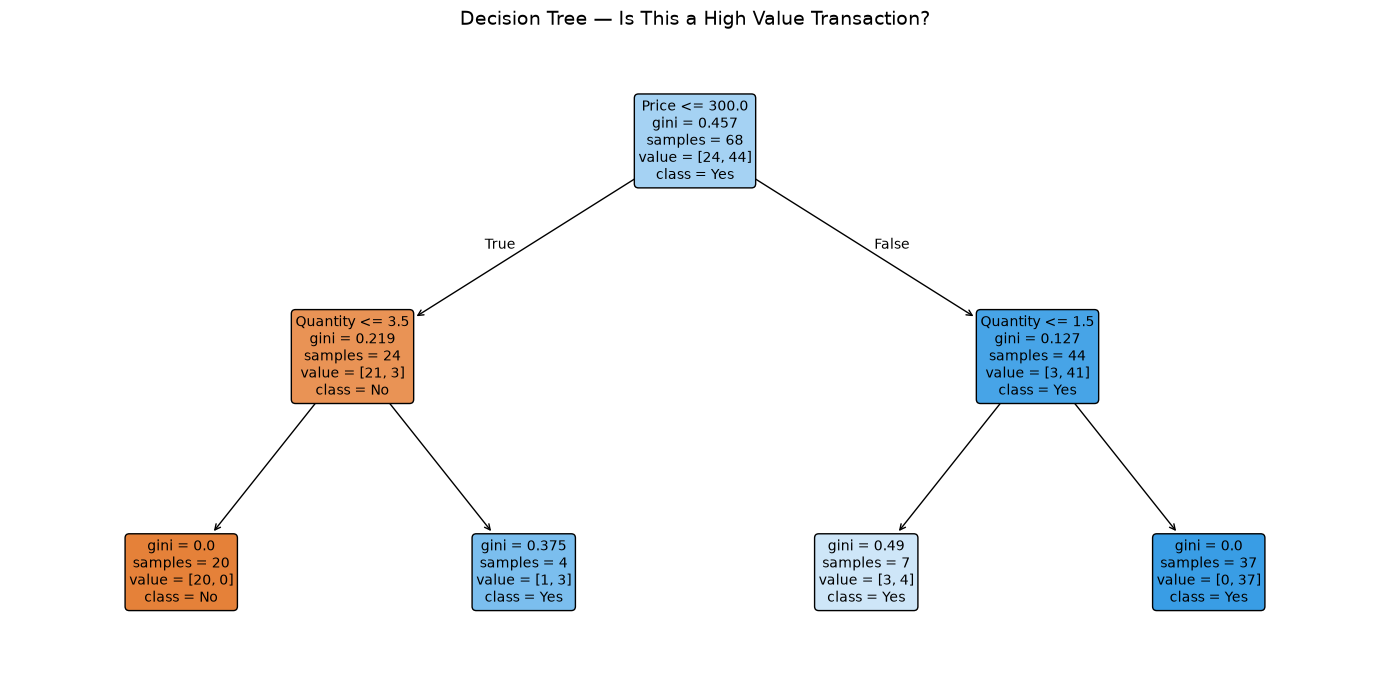

In [10]:
plt.figure(figsize=(14, 7))
plot_tree(
    tree_model,
    feature_names=['Price', 'Quantity'],
    class_names=['No', 'Yes'],
    filled=True,       # colours the boxes
    rounded=True,      # rounded corners
    fontsize=10
)
plt.title("Decision Tree — Is This a High Value Transaction?", fontsize=14)
plt.tight_layout()
plt.show()

**How to read the tree above:**
- Each box shows the **question** being asked (e.g., `Price <= 250`)
- `gini` = how impure the node is (0.0 = perfectly pure, 0.5 = totally mixed)
- `samples` = how many transactions are in that node
- `value` = count of [No, Yes] in that node
- `class` = the majority class (No or Yes)

You can trace any path from **Root** (top) → through **Decision Nodes** (middle) → to a **Leaf** (bottom). That's exactly what the model does for each transaction!

---
## 6. Overfitting — When the Tree Learns *Too* Well

If you let the tree grow without any limits, it will keep splitting until every single training transaction is perfectly classified.

Sounds great, right? **Nope.**

The problem is that it **memorises** the training data — including the noise and outliers. So when new transactions come in, it performs badly.

This is called **overfitting**.

**Analogy:** Imagine a student who memorises every answer from a textbook word-for-word instead of understanding the concepts. They'll ace the textbook questions but fail on anything slightly different.

Let's see it with our sales data 👇

In [11]:
# An overfit tree — no depth limit at all
overfit_tree = DecisionTreeClassifier(random_state=42)  # no max_depth!
overfit_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, overfit_tree.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  overfit_tree.predict(X_test)) * 100

print("--- Overfit Tree (no depth limit) ---")
print(f"  Train accuracy: {train_acc:.1f}%")
print(f"  Test accuracy:  {test_acc:.1f}%")
print()

# Compare with our simpler tree
train_acc2 = accuracy_score(y_train, tree_model.predict(X_train)) * 100
test_acc2  = accuracy_score(y_test,  tree_model.predict(X_test)) * 100

print("--- Simple Tree (max_depth=2) ---")
print(f"  Train accuracy: {train_acc2:.1f}%")
print(f"  Test accuracy:  {test_acc2:.1f}%")

--- Overfit Tree (no depth limit) ---
  Train accuracy: 100.0%
  Test accuracy:  100.0%

--- Simple Tree (max_depth=2) ---
  Train accuracy: 94.1%
  Test accuracy:  82.4%


Notice how the overfit tree gets **100% on training data**? It memorised everything. But on test data it may do the same or worse.

**How to prevent overfitting in trees:**
- `max_depth` — limit how deep the tree can go
- `min_samples_split` — need at least this many samples to split a node
- `min_samples_leaf` — need at least this many samples in each leaf

These are called **hyperparameters** — you set them before training.

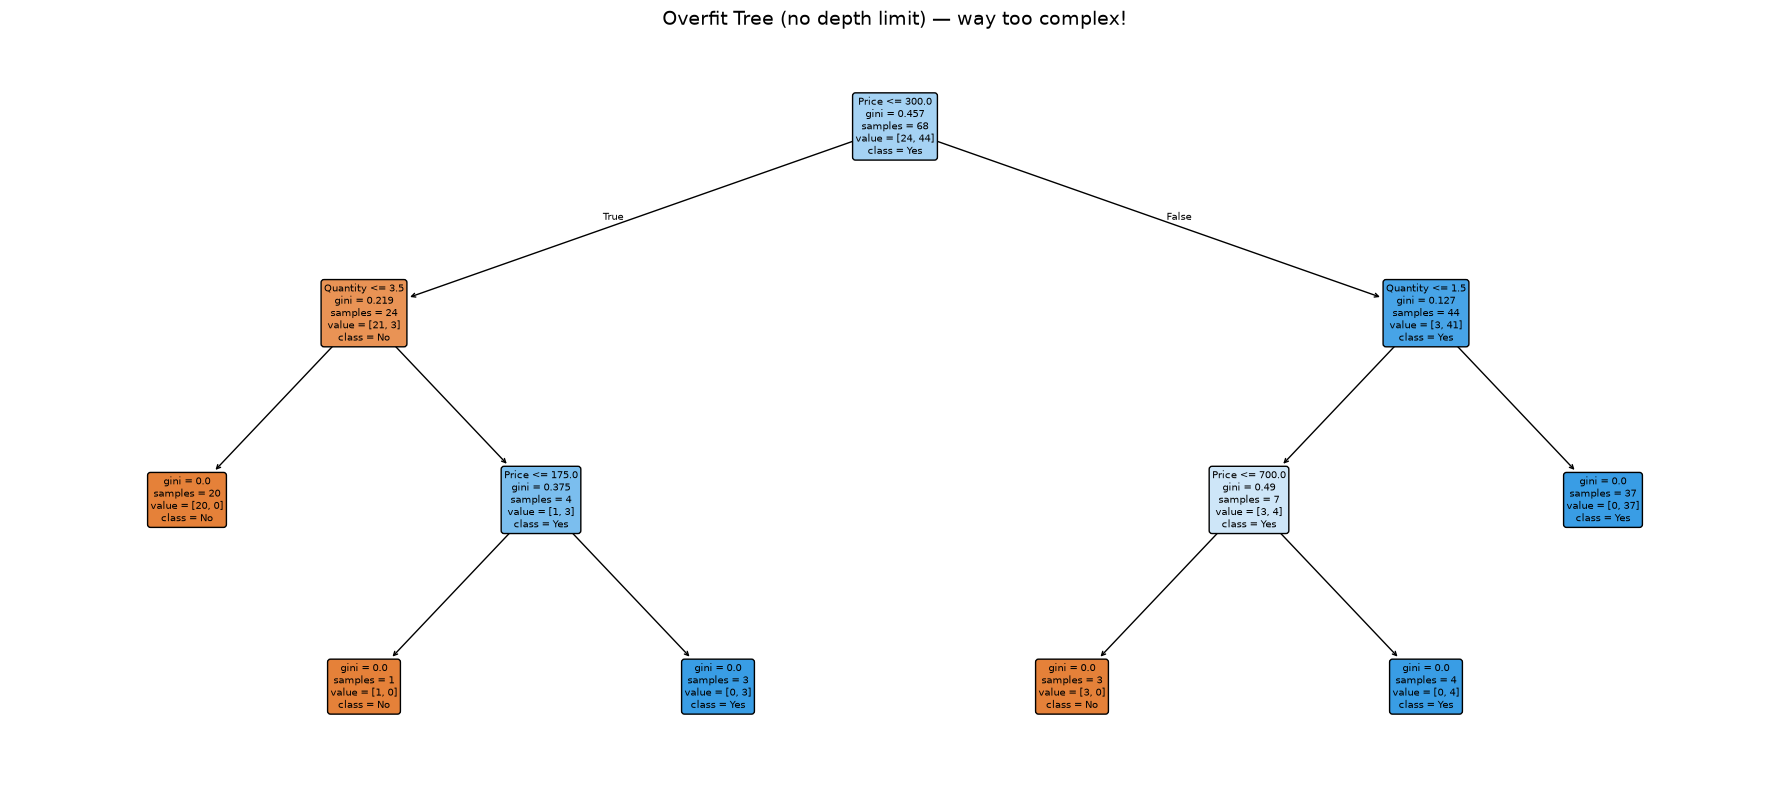

In [12]:
# Let's see how the overfit tree looks — it's way more complex!
plt.figure(figsize=(18, 8))
plot_tree(
    overfit_tree,
    feature_names=['Price', 'Quantity'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Overfit Tree (no depth limit) — way too complex!", fontsize=14)
plt.tight_layout()
plt.show()

Compare this messy tree with our clean 3-level tree above. **Simpler is usually better!**

---
## 7. Why Decision Trees Are Easy to Understand

Decision Trees are one of the few ML models that are **interpretable** — you can explain *why* the model made a certain prediction.

1. **They look like flowcharts** — anyone can follow the path from top to bottom.
2. **No black box** — you can see every question and every split.
3. **Feature importance** — you can tell which features matter most (the ones used higher up in the tree).
4. **No data scaling needed** — trees don't care if Price is in hundreds and Quantity is in single digits.

This makes them great for situations where you need to **explain** your model to someone (a manager, a client, etc.).

Let's check which features our model thinks are most important for deciding High Value transactions 👇

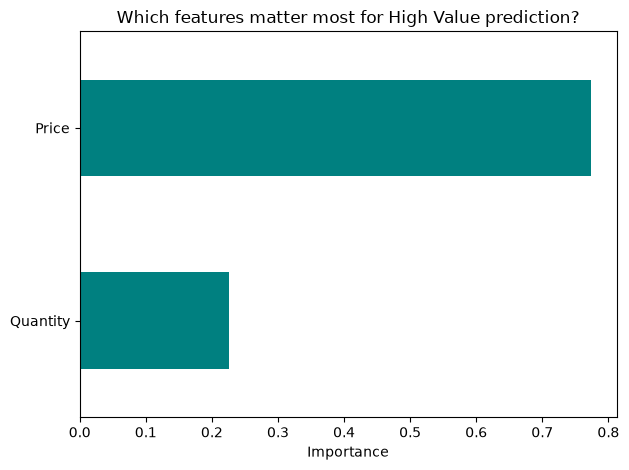


Makes sense! Price is the biggest factor in deciding if a transaction is high value.


In [13]:
# Feature importance from our simple tree
importance = pd.Series(
    tree_model.feature_importances_,
    index=['Price', 'Quantity']
).sort_values(ascending=True)

importance.plot.barh(color='teal')
plt.title("Which features matter most for High Value prediction?")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print()
print("Makes sense! Price is the biggest factor in deciding if a transaction is high value.")

---
## Quick Recap

| Topic | Key Takeaway |
|-------|-------------|
| What is a Decision Tree? | A flowchart-like model that splits data by asking yes/no questions |
| Real-life example | "Is this transaction high value?" — check Price first, then Quantity |
| Root Node | First question at the top (e.g., *Price <= 250?*) |
| Decision Node | Follow-up questions in the middle |
| Leaf Node | Final answer — "Yes" or "No", no more splits |
| How it picks questions | Chooses the split that makes groups most pure (Gini) |
| Overfitting | Tree memorises training data if you don't limit its depth |
| Why trees are easy | Interpretable, visual, no scaling needed, shows feature importance |

---
*Day 3 done ✅ — Next up we can explore Random Forests, which are just a bunch of decision trees working together!*